# ETH/UCY Scene Occupancy Maps\n\nVisualise the top-down walkability maps generated from pedestrian trajectory density.\n\nEach map is a `(3, 224, 224)` float tensor with values in **[0, 1]**:\n- **1.0** (bright) → heavily trafficked / known walkable area  \n- **0.0** (dark) → unobserved — potential obstacle or out-of-scene region"

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.ndimage import binary_dilation, binary_fill_holes, generate_binary_structure

from data.eth_ucy import (
    download_all_scenes, load_scene, SceneExtent,
    build_occupancy_map, MAP_SIZE,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "font.size": 9})

## Load all scenes

In [2]:
from pathlib import Path

ROOT = Path("data/eth_ucy")
SCENES = ["eth", "hotel", "univ", "zara1", "zara2"]

scene_paths = download_all_scenes(ROOT)

scene_raw    = {}
scene_extent = {}
scene_map    = {}

for scene in SCENES:
    raw = load_scene(scene_paths[scene])
    ext = SceneExtent(raw, margin=2.0)
    occ = build_occupancy_map(raw, ext, size=MAP_SIZE, sigma_px=3.0)
    scene_raw[scene]    = raw
    scene_extent[scene] = ext
    scene_map[scene]    = occ
    print(
        f"{scene:6s}  "
        f"x=[{ext.x_min:6.1f}, {ext.x_max:5.1f}] m  "
        f"y=[{ext.y_min:6.1f}, {ext.y_max:5.1f}] m  "
        f"map dtype={occ.dtype}  shape={tuple(occ.shape)}  "
        f"range=[{occ.min():.3f}, {occ.max():.3f}]"
    )

eth     x=[  -9.7,  16.4] m  y=[  -5.2,  15.2] m  map dtype=torch.float32  shape=(3, 224, 224)  range=[0.000, 1.000]
hotel   x=[  -5.2,   6.3] m  y=[ -12.3,   6.3] m  map dtype=torch.float32  shape=(3, 224, 224)  range=[0.000, 1.000]
univ    x=[  -2.5,  17.5] m  y=[  -2.3,  15.9] m  map dtype=torch.float32  shape=(3, 224, 224)  range=[0.000, 1.000]
zara1   x=[  -2.1,  17.5] m  y=[  -2.4,  14.4] m  map dtype=torch.float32  shape=(3, 224, 224)  range=[0.000, 1.000]
zara2   x=[  -2.4,  17.6] m  y=[  -2.3,  15.9] m  map dtype=torch.float32  shape=(3, 224, 224)  range=[0.000, 1.000]


## Helper — infer walkable area and obstacles from trajectory density

In [3]:
def infer_walkable_obstacle(
    density: np.ndarray,          # (H, W)  float in [0, 1]
    metres_per_px: tuple,         # (dx, dy)
    density_thresh: float = 0.02, # cells above this → walkable seeds
    dilation_m: float = 1.5,      # grow walkable region by this many metres
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    From a trajectory-density map, produce three binary masks:

      walkable  — cells reachable by pedestrians (density > thresh, then dilated)
      obstacle  — enclosed holes inside the walkable footprint
                  (physically: pillars, buildings, fixtures that people walk around)
      boundary  — everything outside the walkable footprint
                  (unobserved / scene edge)

    Returns
    -------
    walkable, obstacle, boundary  — each (H, W) bool array
    """
    dx_m, dy_m = metres_per_px

    # 1. Seed: cells with any recorded trajectory
    seeds = density > density_thresh                               # (H, W) bool

    # 2. Dilate seeds by `dilation_m` metres to close gaps between paths
    #    Convert metres → pixels separately per axis; use the coarser one for a
    #    circular-ish structuring element.
    px_radius = max(1, int(round(dilation_m / max(dx_m, dy_m))))
    y, x = np.ogrid[-px_radius:px_radius+1, -px_radius:px_radius+1]
    disk = (x**2 + y**2) <= px_radius**2
    walkable = binary_dilation(seeds, structure=disk)              # (H, W) bool

    # 3. Fill holes: regions *completely enclosed* by walkable cells → obstacles
    #    binary_fill_holes treats False-border pixels as "outside".
    filled = binary_fill_holes(walkable)                           # (H, W) bool
    obstacle = filled & ~walkable                                  # enclosed holes

    # 4. Everything outside the filled footprint → unobserved boundary
    boundary = ~filled

    return walkable, obstacle, boundary


def build_rgb_map(
    walkable: np.ndarray,
    obstacle: np.ndarray,
    boundary: np.ndarray,
    density: np.ndarray,
) -> np.ndarray:
    """
    Compose a colour RGB image from the three masks.

    Colour scheme
    -------------
    walkable  → green  (intensity ∝ density, so high-traffic paths are brighter)
    obstacle  → red
    boundary  → dark grey (unobserved / outside scene)
    """
    H, W = density.shape
    rgb = np.zeros((H, W, 3), dtype=np.float32)

    # Boundary: dark grey
    rgb[boundary] = [0.15, 0.15, 0.15]

    # Obstacle: solid red
    rgb[obstacle] = [0.85, 0.15, 0.10]

    # Walkable: green, with brightness ∝ local density
    #   map density [0,1] → brightness [0.25, 1.0] so even low-traffic areas are visible
    brightness = 0.25 + 0.75 * np.clip(density / (density.max() + 1e-8), 0, 1)
    rgb[walkable, 0] = 0.10 * brightness[walkable]
    rgb[walkable, 1] = 0.75 * brightness[walkable]
    rgb[walkable, 2] = 0.20 * brightness[walkable]

    return rgb

print("Helper functions defined.")

Helper functions defined.


## Figure 1 — Walkable / Obstacle maps for all five scenes

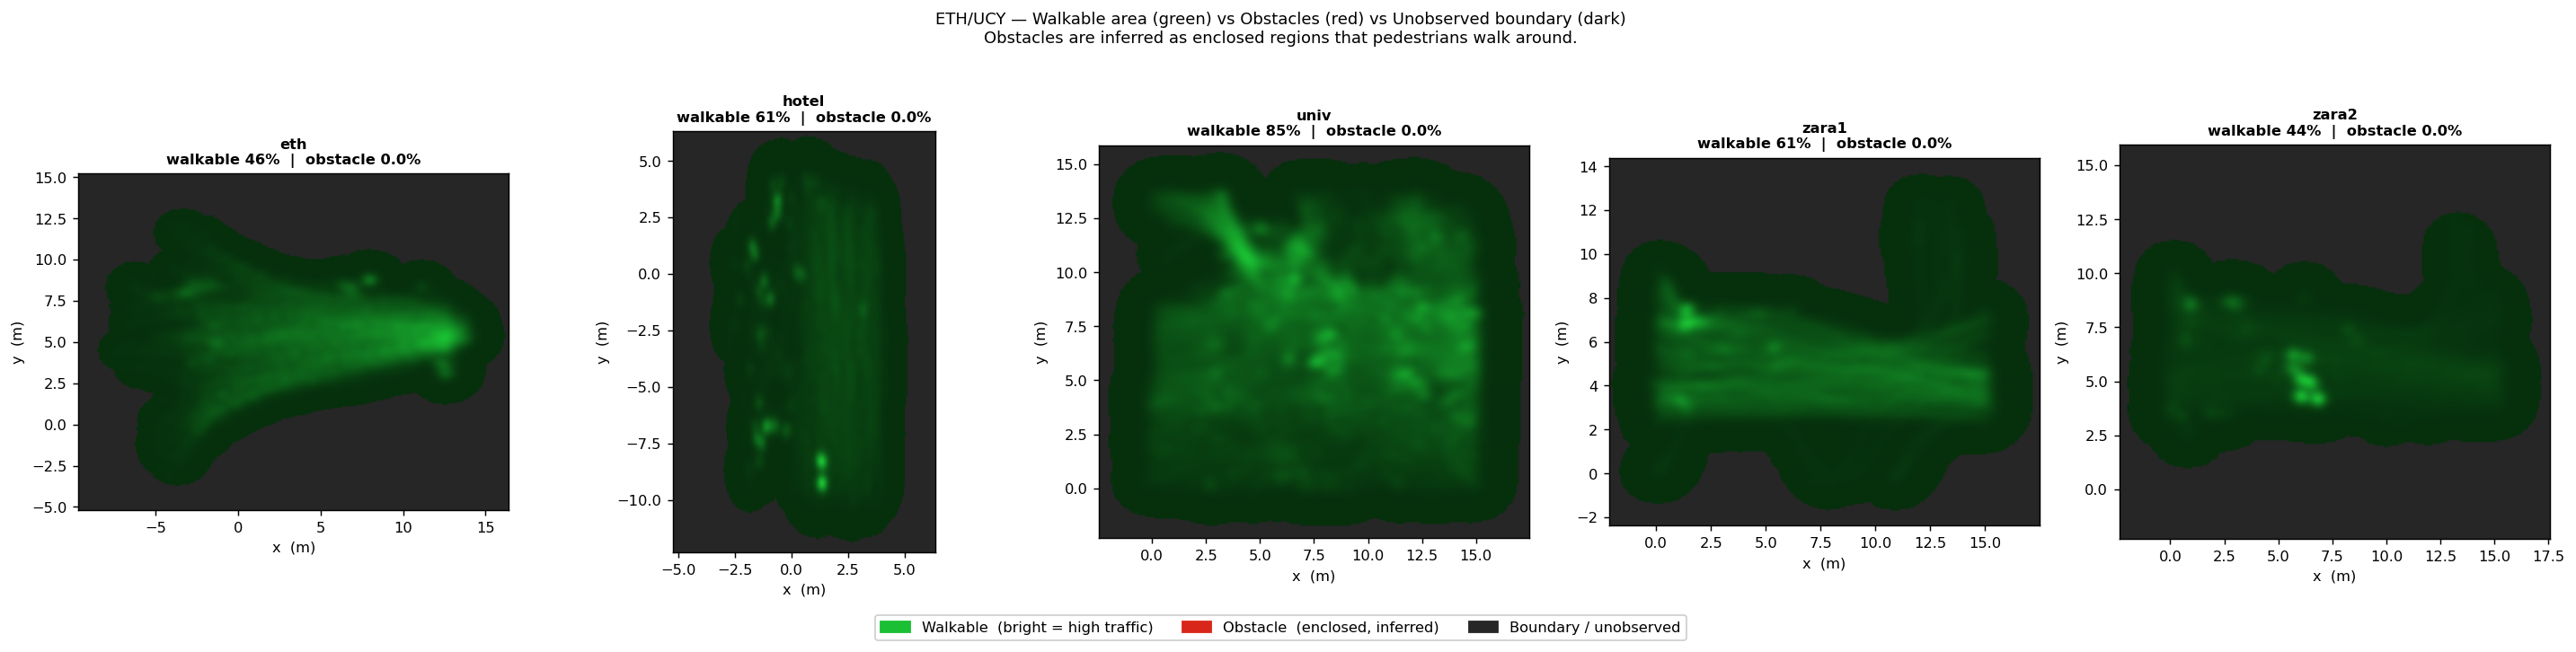

In [4]:
legend_patches = [
    mpatches.Patch(color=(0.10, 0.75, 0.20), label="Walkable  (bright = high traffic)"),
    mpatches.Patch(color=(0.85, 0.15, 0.10), label="Obstacle  (enclosed, inferred)"),
    mpatches.Patch(color=(0.15, 0.15, 0.15), label="Boundary / unobserved"),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle(
    "ETH/UCY — Walkable area (green) vs Obstacles (red) vs Unobserved boundary (dark)\n"
    "Obstacles are inferred as enclosed regions that pedestrians walk around.",
    fontsize=10, y=1.03,
)

for ax, scene in zip(axes, SCENES):
    density = scene_map[scene][0].numpy()
    ext     = scene_extent[scene]
    mpp     = ext.metres_per_pixel(MAP_SIZE)

    walkable, obstacle, boundary = infer_walkable_obstacle(density, mpp)
    rgb = build_rgb_map(walkable, obstacle, boundary, density)

    n_walk = walkable.sum()
    n_obs  = obstacle.sum()
    pct_walk = 100 * n_walk / density.size
    pct_obs  = 100 * n_obs  / density.size

    ax.imshow(
        rgb,
        origin="lower",
        extent=[ext.x_min, ext.x_max, ext.y_min, ext.y_max],
        aspect="equal",
    )
    ax.set_title(
        f"{scene}\n"
        f"walkable {pct_walk:.0f}%  |  obstacle {pct_obs:.1f}%",
        fontweight="bold", fontsize=9,
    )
    ax.set_xlabel("x  (m)")
    ax.set_ylabel("y  (m)")

fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.06), framealpha=0.9)
plt.tight_layout()
plt.savefig("map_walkable.png", bbox_inches="tight", dpi=150)
plt.show()

## Figure 2 — Per-scene detail: density → seeds → walkable → obstacles (pipeline)

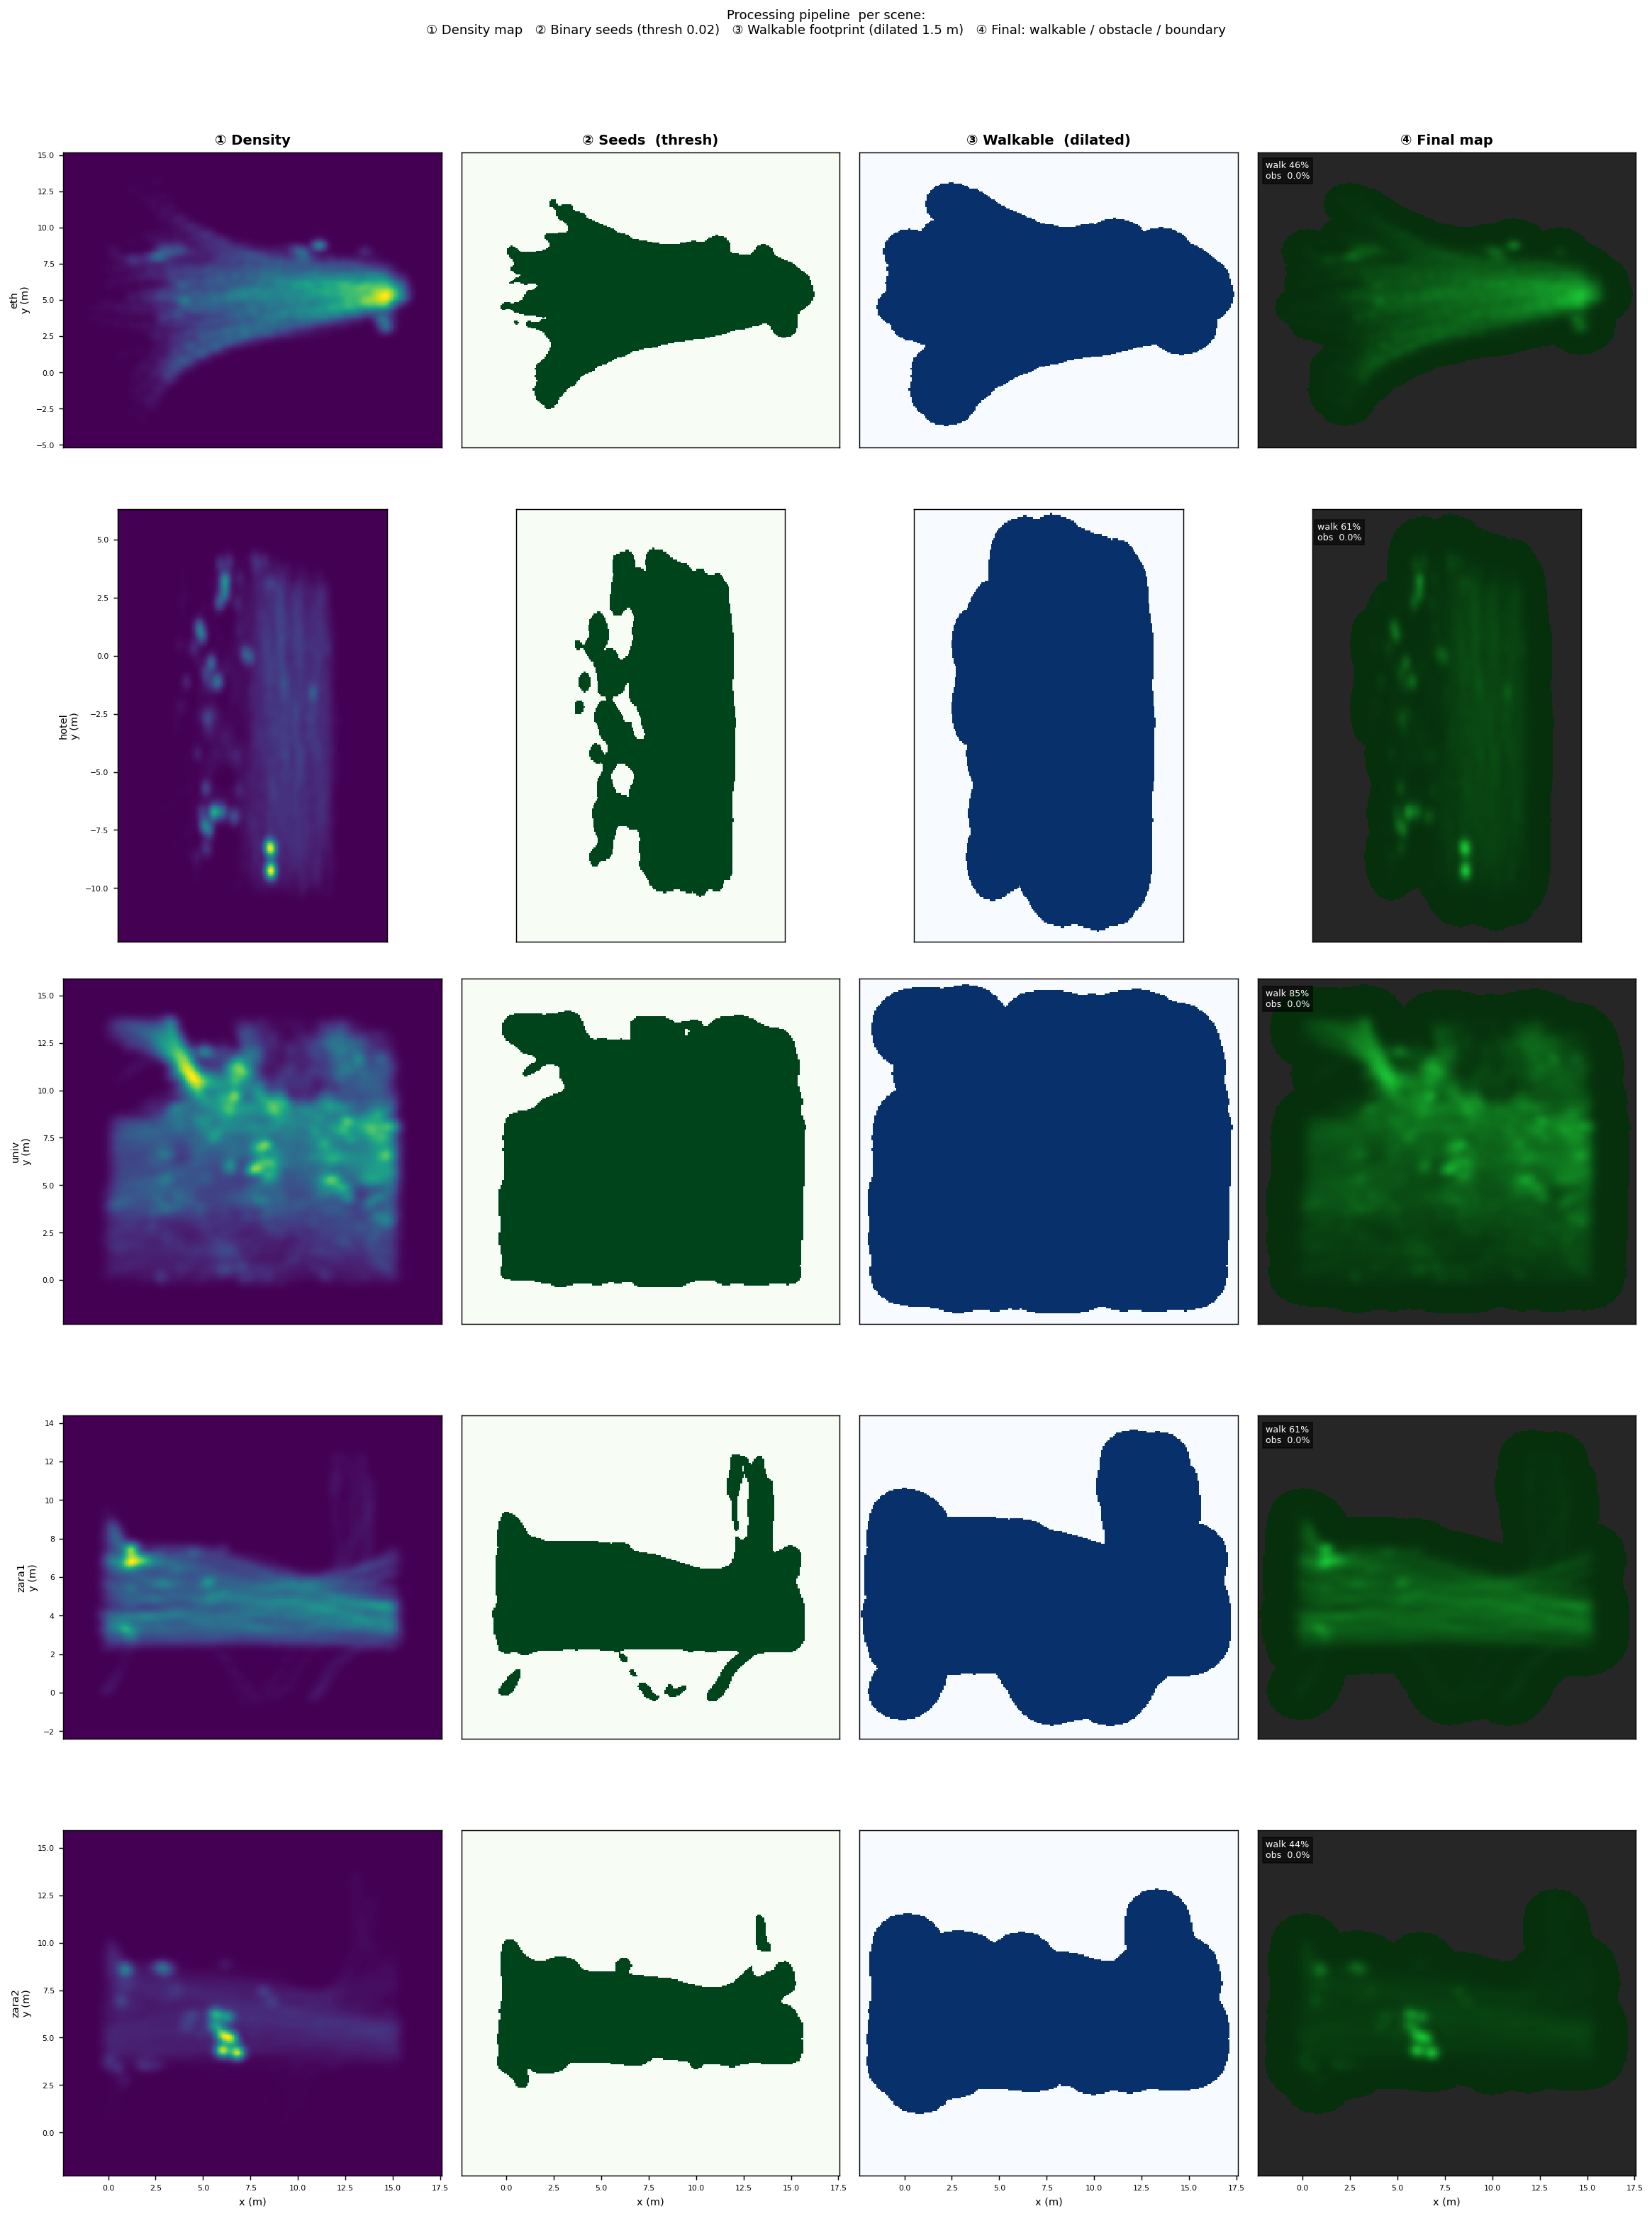

In [5]:
fig, axes = plt.subplots(5, 4, figsize=(18, 24))
fig.suptitle(
    "Processing pipeline  per scene:\n"
    "① Density map   ② Binary seeds (thresh 0.02)   "
    "③ Walkable footprint (dilated 1.5 m)   ④ Final: walkable / obstacle / boundary",
    fontsize=10, y=1.01,
)

STEP_TITLES = ["① Density", "② Seeds  (thresh)", "③ Walkable  (dilated)", "④ Final map"]

for row, scene in enumerate(SCENES):
    density = scene_map[scene][0].numpy()
    ext     = scene_extent[scene]
    mpp     = ext.metres_per_pixel(MAP_SIZE)
    E       = dict(extent=[ext.x_min, ext.x_max, ext.y_min, ext.y_max],
                   origin="lower", aspect="equal")

    walkable, obstacle, boundary = infer_walkable_obstacle(density, mpp)
    rgb = build_rgb_map(walkable, obstacle, boundary, density)

    seeds = density > 0.02

    imgs = [
        (density, "viridis",  dict(vmin=0, vmax=1)),
        (seeds.astype(float), "Greens", dict(vmin=0, vmax=1)),
        (walkable.astype(float), "Blues", dict(vmin=0, vmax=1)),
        (rgb, None, {}),
    ]

    for col, (img, cmap, kwargs) in enumerate(imgs):
        ax = axes[row, col]
        if cmap is not None:
            im = ax.imshow(img, cmap=cmap, interpolation="nearest", **E, **kwargs)
        else:
            ax.imshow(img, interpolation="nearest", **E)

        if row == 0:
            ax.set_title(STEP_TITLES[col], fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{scene}\ny (m)", fontsize=8)
        else:
            ax.set_ylabel("")
            ax.set_yticks([])
        if row == 4:
            ax.set_xlabel("x (m)", fontsize=8)
        else:
            ax.set_xticks([])

        ax.tick_params(labelsize=6)

        # Annotate stats on final map
        if col == 3:
            pct_w = 100 * walkable.sum() / density.size
            pct_o = 100 * obstacle.sum() / density.size
            ax.text(0.02, 0.97,
                    f"walk {pct_w:.0f}%\nobs  {pct_o:.1f}%",
                    transform=ax.transAxes, va="top", ha="left",
                    fontsize=7, color="white",
                    bbox=dict(fc="black", alpha=0.55, pad=2))

plt.tight_layout()
plt.savefig("map_pipeline.png", bbox_inches="tight", dpi=130)
plt.show()